# Asset 0 — Health Monitoring Pipeline (Fixed)

Complete pipeline: preprocessing → feature engineering → Isolation Forest → XGBoost → evaluation

In [21]:
# ── Cell 1: Imports & Load Data ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'text.color':       '#cccccc',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.5,
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'font.family':      'monospace',
})

url = "https://raw.githubusercontent.com/HumanCenteredTechnology/SME-Manufacturing-Dataset/main/company_A.csv"
df_raw = pd.read_csv(url)
df_raw['ts'] = pd.to_datetime(df_raw['ts'], utc=True)
df_raw = df_raw.sort_values('ts').reset_index(drop=True)

df0 = df_raw[df_raw['asset'] == 0].copy().reset_index(drop=True)

print(f"Asset 0 rows     : {len(df0):,}")
print(f"Date range       : {df0['ts'].min()} → {df0['ts'].max()}")
print(f"Status counts    :\n{df0['status'].value_counts().sort_index()}")
print(f"Alarm rate       : {df0['alarm'].mean():.4f}")
print(f"Zero power ratio : {(df0['power_avg']==0).mean():.4f}")

Asset 0 rows     : 175,063
Date range       : 2021-03-30 14:17:50+00:00 → 2022-10-27 12:55:00+00:00
Status counts    :
status
1.0    67951
2.0    66546
3.0    40566
Name: count, dtype: int64
Alarm rate       : 0.2317
Zero power ratio : 0.5100


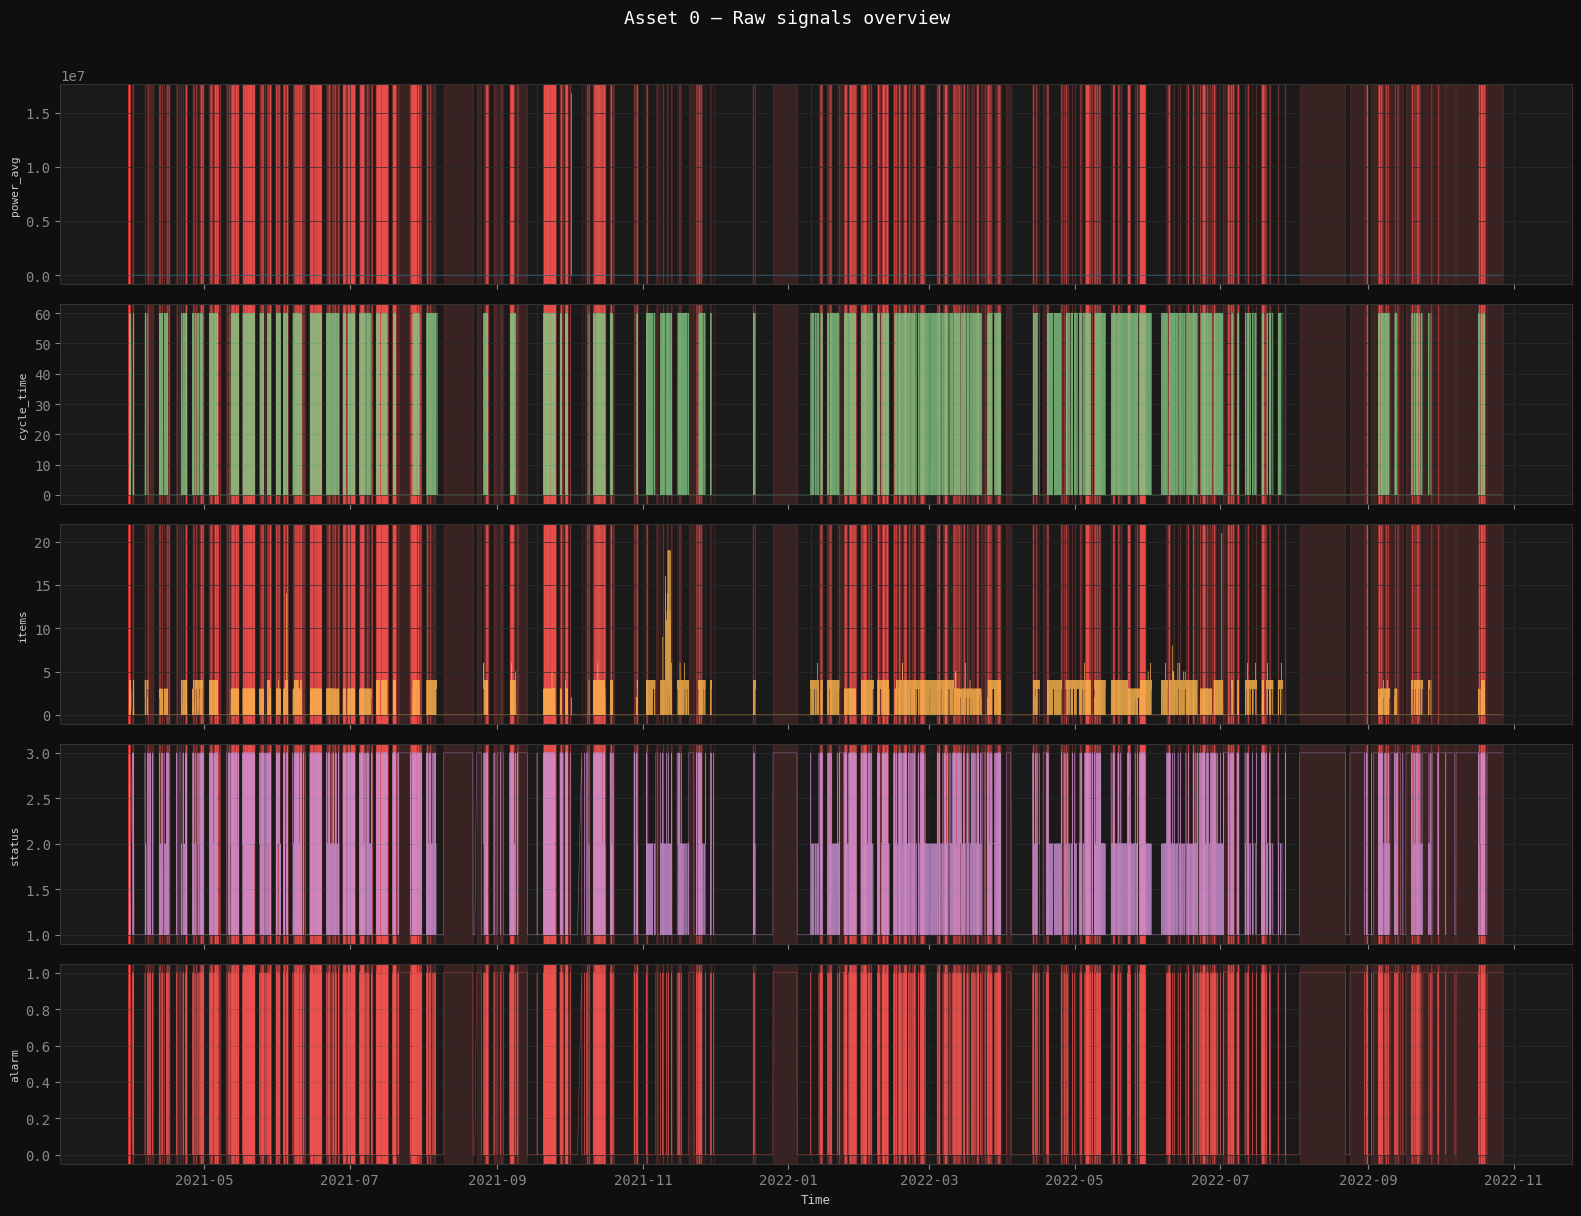


── Raw descriptive stats ──
          power_avg  cycle_time       items  status_time
count  1.750630e+05  175063.000  175063.000   175063.000
mean   9.780000e+01      21.112       1.135       56.927
std    4.009800e+04      28.653       1.562       11.880
min    0.000000e+00       0.000       0.000        0.000
25%    0.000000e+00       0.000       0.000       60.000
50%    0.000000e+00       0.000       0.000       60.000
75%    5.000000e+00      60.000       3.000       60.000
max    1.677722e+07      60.000      21.000       60.000


In [22]:
# ── Cell 2: Raw signal overview ──────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Asset 0 — Raw signals overview', y=1.01, fontsize=13, color='white')

cols   = ['power_avg', 'cycle_time', 'items', 'status', 'alarm']
colors = ['#4fc3f7', '#81c784', '#ffb74d', '#ce93d8', '#ef5350']

for ax, col, color in zip(axes, cols, colors):
    ax.plot(df0['ts'], df0[col], color=color, linewidth=0.3, alpha=0.8)
    ax.set_ylabel(col, fontsize=8)
    ax.grid(True)
    mask = df0['status'] == 3.0
    for _, grp in df0[mask].groupby((~mask).cumsum()):
        ax.axvspan(grp['ts'].iloc[0], grp['ts'].iloc[-1], alpha=0.15, color='#ef5350', zorder=0)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('01_raw_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Raw descriptive stats ──")
print(df0[['power_avg','cycle_time','items','status_time']].describe().round(3))

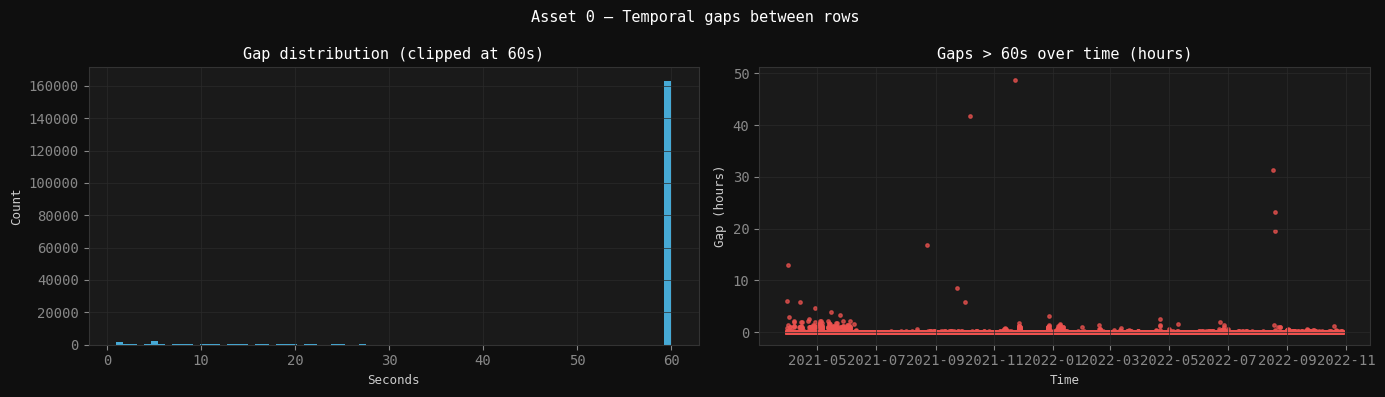

Median gap   : 300.0s
Gaps > 60s   : 163176
Gaps > 5min  : 1019
Gaps > 1hr   : 110
Max gap      : 48.74 hrs


In [23]:
# ── Cell 3: Temporal gap analysis ────────────────────────────────────────────
df0['ts_diff'] = df0['ts'].diff().dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Asset 0 — Temporal gaps between rows', fontsize=11, color='white')

axes[0].hist(df0['ts_diff'].clip(upper=60).dropna(), bins=80,
             color='#4fc3f7', edgecolor='none', alpha=0.85)
axes[0].set_title('Gap distribution (clipped at 60s)')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Count')
axes[0].grid(True)

large_gaps = df0[df0['ts_diff'] > 60]
axes[1].scatter(large_gaps['ts'], large_gaps['ts_diff'] / 3600,
                color='#ef5350', s=6, alpha=0.7)
axes[1].set_title('Gaps > 60s over time (hours)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Gap (hours)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('02_temporal_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median gap   : {df0['ts_diff'].median():.1f}s")
print(f"Gaps > 60s   : {(df0['ts_diff'] > 60).sum()}")
print(f"Gaps > 5min  : {(df0['ts_diff'] > 300).sum()}")
print(f"Gaps > 1hr   : {(df0['ts_diff'] > 3600).sum()}")
print(f"Max gap      : {df0['ts_diff'].max()/3600:.2f} hrs")

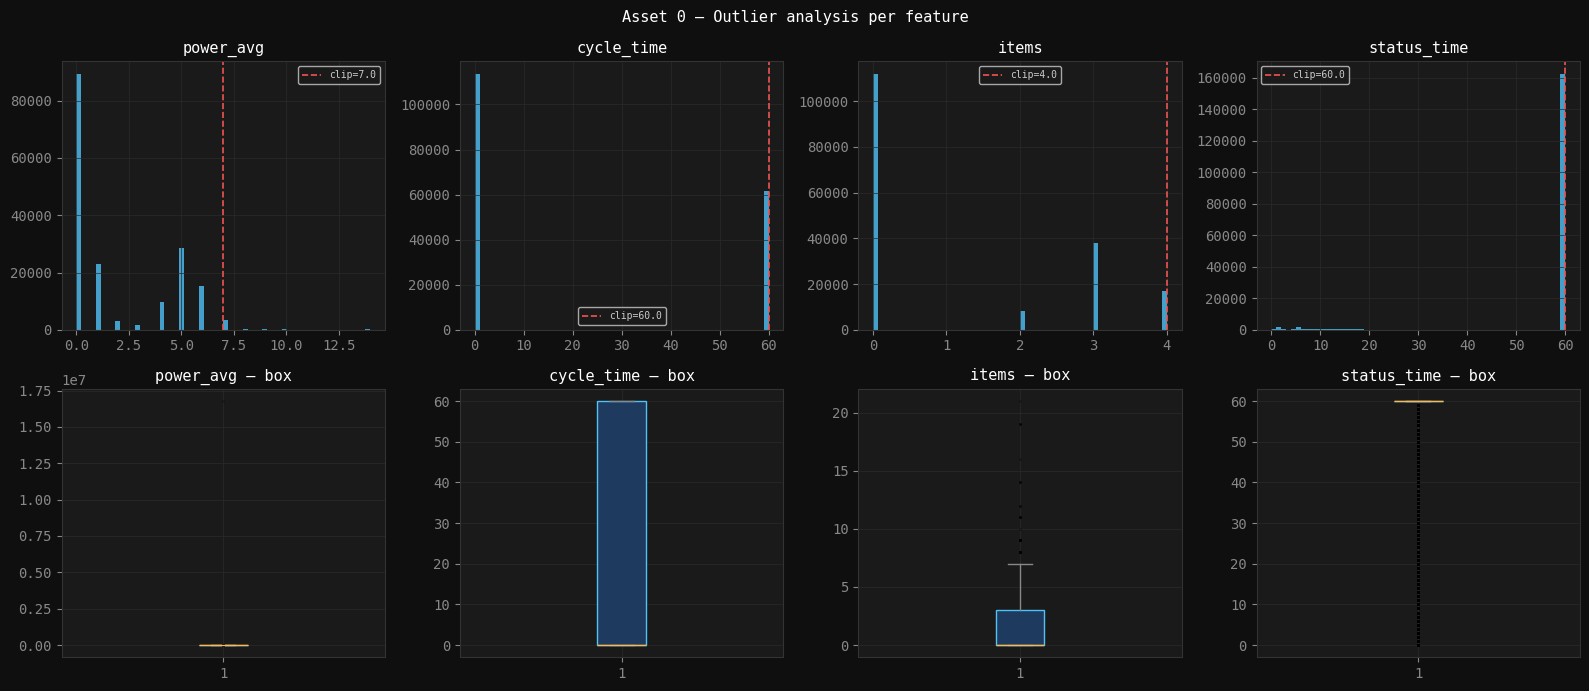


── Clip thresholds (3×IQR capped at p99) ──
  power_avg        lower=0.0  upper=7.0
  cycle_time       lower=0.0  upper=60.0
  items            lower=0.0  upper=4.0
  status_time      lower=0.0  upper=60.0


In [24]:
# ── Cell 4: Outlier analysis & clip thresholds ───────────────────────────────
features = ['power_avg', 'cycle_time', 'items', 'status_time']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Asset 0 — Outlier analysis per feature', fontsize=11, color='white')

clip_thresholds = {}

for i, feat in enumerate(features):
    series = df0[feat]
    p25, p75, p99 = series.quantile([0.25, 0.75, 0.99])
    iqr   = p75 - p25
    upper = min(p75 + 3.0 * iqr, p99)
    clip_thresholds[feat] = {'lower': 0.0, 'upper': round(upper, 4)}

    ax = axes[0, i]
    ax.hist(series.clip(upper=series.quantile(0.999)), bins=60,
            color='#4fc3f7', alpha=0.8, edgecolor='none')
    ax.axvline(upper, color='#ef5350', linewidth=1.2, linestyle='--',
               label=f'clip={upper:.1f}')
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.grid(True)

    ax2 = axes[1, i]
    ax2.boxplot(series.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#1e3a5f', color='#4fc3f7'),
                medianprops=dict(color='#ffb74d'),
                whiskerprops=dict(color='#888888'),
                capprops=dict(color='#888888'),
                flierprops=dict(marker='.', color='#ef5350', markersize=2, alpha=0.3))
    ax2.set_title(f'{feat} — box')
    ax2.grid(True)

plt.tight_layout()
plt.savefig('03_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Clip thresholds (3×IQR capped at p99) ──")
for k, v in clip_thresholds.items():
    print(f"  {k:15s}  lower={v['lower']}  upper={v['upper']}")

In [25]:
# ── Cell 5: Clean & clip ──────────────────────────────────────────────────────
df1 = df0.copy()

# Clip outliers
for feat, bounds in clip_thresholds.items():
    df1[feat] = df1[feat].clip(lower=bounds['lower'], upper=bounds['upper'])

# Binary machine-on flag
df1['is_on'] = (df1['power_avg'] > 0).astype(int)

# Forward-fill status
df1['status'] = df1['status'].ffill()

# Session break flag (gap > 5 min)
df1['session_break'] = (df1['ts_diff'] > 300).fillna(False).astype(int)
df1['session_id']    = df1['session_break'].cumsum()

print(f"Rows after clipping       : {len(df1):,}")
print(f"is_on=1 (machine running) : {df1['is_on'].sum():,} ({df1['is_on'].mean():.2%})")
print(f"Session breaks (>5min)    : {df1['session_break'].sum()}")
print(f"Total sessions            : {df1['session_id'].nunique()}")

Rows after clipping       : 175,063
is_on=1 (machine running) : 85,775 (49.00%)
Session breaks (>5min)    : 1019
Total sessions            : 1020


In [26]:
# ── Cell 6 (REVISED): Rolling features + pre_alarm label ─────────────────────
# FIX: removed time_in_status (leakage). Added time_since_alarm (backward-looking).
# FIX: added forward-looking pre_alarm label so XGB predicts BEFORE the event.

W_MEDIUM = 60
W_LONG   = 180

def rolling_per_session(series, session_ids, window, func='mean'):
    out = pd.Series(index=series.index, dtype=float)
    for sid, grp_idx in series.groupby(session_ids).groups.items():
        s = series.loc[grp_idx]
        if func == 'mean':
            out.loc[grp_idx] = s.rolling(window, min_periods=max(1, window//4)).mean()
        elif func == 'std':
            out.loc[grp_idx] = s.rolling(window, min_periods=max(2, window//4)).std()
    return out

sid = df1['session_id']

# Core features
df1['power_roll_mean_m'] = rolling_per_session(df1['power_avg'],  sid, W_MEDIUM, 'mean')
df1['power_roll_std_m']  = rolling_per_session(df1['power_avg'],  sid, W_MEDIUM, 'std')
df1['power_diff_abs']    = df1['power_avg'].diff().abs().fillna(0)
df1['cycle_roll_mean_l'] = rolling_per_session(df1['cycle_time'], sid, W_LONG,   'mean')
df1['alarm_roll_m']      = rolling_per_session(df1['alarm'].astype(float), sid, W_MEDIUM, 'mean')

# ── time_since_alarm: counts rows since last status-3 event (backward, no leakage)
alarm_flag = (df1['status'] == 3.0).values
counter = 0
time_since_alarm = []
for flag in alarm_flag:
    if flag:
        counter = 0
    else:
        counter += 1
    time_since_alarm.append(counter)
df1['time_since_alarm'] = time_since_alarm

# ── pre_alarm: 1 if status becomes 3 within next LOOKAHEAD rows (forward-looking label)
LOOKAHEAD = 30
status3_flag = (df1['status'] == 3.0).astype(float)
df1['pre_alarm'] = (
    status3_flag
    .iloc[::-1]
    .rolling(LOOKAHEAD, min_periods=1)
    .max()
    .iloc[::-1]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

FEATURE_COLS_IF = [
    'power_roll_mean_m',
    'power_roll_std_m',
    'power_diff_abs',
    'time_since_alarm',
]

FEATURE_COLS_XGB = FEATURE_COLS_IF + [
    'cycle_roll_mean_l',
    'is_on',
    'alarm_roll_m',
]

print(f"NaN counts in IF features:")
print(df1[FEATURE_COLS_IF].isnull().sum())
print(f"\npre_alarm rate  : {df1['pre_alarm'].mean():.4f}")
print(f"pre_alarm count : {df1['pre_alarm'].sum():,}")
print(f"status-3 count  : {(df1['status']==3.0).sum():,}")

NaN counts in IF features:
power_roll_mean_m    6846
power_roll_std_m     6846
power_diff_abs          0
time_since_alarm        0
dtype: int64

pre_alarm rate  : 0.4466
pre_alarm count : 78,176
status-3 count  : 40,566


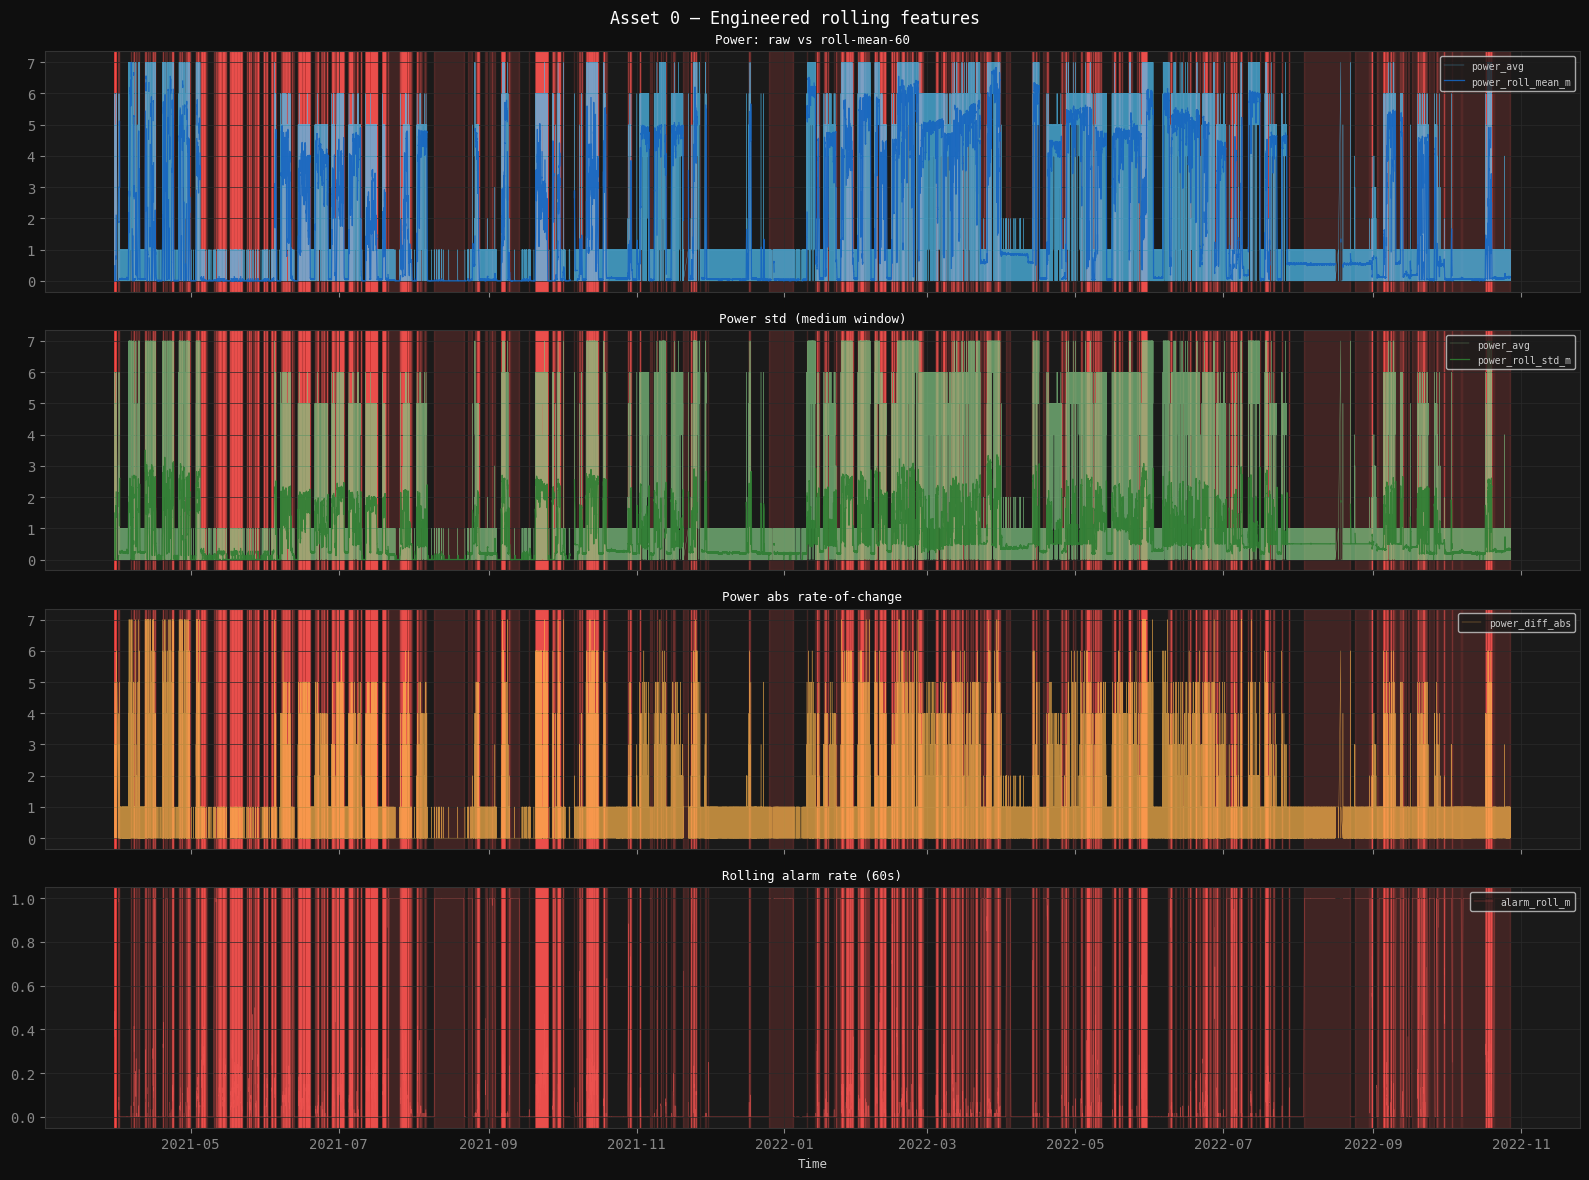

Columns available: ['ts', 'status', 'alarm', 'is_on', 'power_roll_mean_m', 'power_roll_std_m', 'power_diff_abs', 'cycle_roll_mean_l', 'alarm_roll_m', 'time_since_alarm', 'pre_alarm']


In [27]:
# ── Cell 7: Visualise rolling features ───────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Asset 0 — Engineered rolling features', fontsize=12, color='white')

plot_pairs = [
    ('power_avg',      'power_roll_mean_m', '#4fc3f7', '#1565c0', 'Power: raw vs roll-mean-60'),
    ('power_avg',      'power_roll_std_m',  '#81c784', '#2e7d32', 'Power std (medium window)'),
    ('power_diff_abs', None,                '#ffb74d', None,      'Power abs rate-of-change'),
    ('alarm_roll_m',   None,                '#ef5350', None,      'Rolling alarm rate (60s)'),
]

for ax, (col1, col2, c1, c2, title) in zip(axes, plot_pairs):
    ax.plot(df1['ts'], df1[col1], color=c1, linewidth=0.3, alpha=0.7, label=col1)
    if col2:
        ax.plot(df1['ts'], df1[col2], color=c2, linewidth=0.9, alpha=0.9, label=col2)
    mask = df1['status'] == 3.0
    for _, grp in df1[mask].groupby((~mask).cumsum()):
        ax.axvspan(grp['ts'].iloc[0], grp['ts'].iloc[-1],
                   alpha=0.18, color='#ef5350', zorder=0)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('04_rolling_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Columns available:", [c for c in df1.columns if c in
      FEATURE_COLS_IF + FEATURE_COLS_XGB + ['pre_alarm', 'ts', 'status', 'alarm', 'is_on']])

In [28]:
# ── Cell 8 (REVISED): Drop NaN, split normal vs anomaly ──────────────────────
# FIX: use pre_alarm to exclude upcoming-alarm rows from normal training set.

all_needed_cols = list(set(FEATURE_COLS_IF + FEATURE_COLS_XGB +
    ['ts', 'status', 'alarm', 'session_id', 'pre_alarm', 'is_on']))

df2 = df1[all_needed_cols].dropna(subset=FEATURE_COLS_IF).reset_index(drop=True)

# Normal: not in alarm, not pre-alarm, running
df_normal = df2[
    (df2['status'].isin([1.0, 2.0])) &
    (df2['alarm'] == 0) &
    (df2['pre_alarm'] == 0)
].copy()

# Anomaly: in alarm state OR pre-alarm window
df_anomaly = df2[
    (df2['status'] == 3.0) |
    (df2['alarm'] == 1) |
    (df2['pre_alarm'] == 1)
].copy()

print(f"Total usable rows : {len(df2):,}")
print(f"Normal rows       : {len(df_normal):,}  ({len(df_normal)/len(df2):.2%})")
print(f"Anomaly rows      : {len(df_anomaly):,}  ({len(df_anomaly)/len(df2):.2%})")

Total usable rows : 168,217
Normal rows       : 93,128  (55.36%)
Anomaly rows      : 75,089  (44.64%)


In [29]:
# ── Cell 9: Normalise (RobustScaler) ─────────────────────────────────────────
from sklearn.preprocessing import RobustScaler

scaler_check = RobustScaler()
X_normal_scaled = scaler_check.fit_transform(df_normal[FEATURE_COLS_IF])
df_normal_scaled = pd.DataFrame(X_normal_scaled, columns=FEATURE_COLS_IF)

print("── Scaled normal data stats ──")
print(df_normal_scaled.describe().round(3))

── Scaled normal data stats ──
       power_roll_mean_m  power_roll_std_m  power_diff_abs  time_since_alarm
count          93128.000         93128.000       93128.000         93128.000
mean               0.300             0.294           0.420             0.531
std                0.505             0.717           0.686             1.419
min               -0.188            -0.474           0.000            -0.441
25%               -0.176            -0.262           0.000            -0.293
50%                0.000             0.000           0.000             0.000
75%                0.824             0.738           1.000             0.707
max                1.357             2.768           7.000             9.096


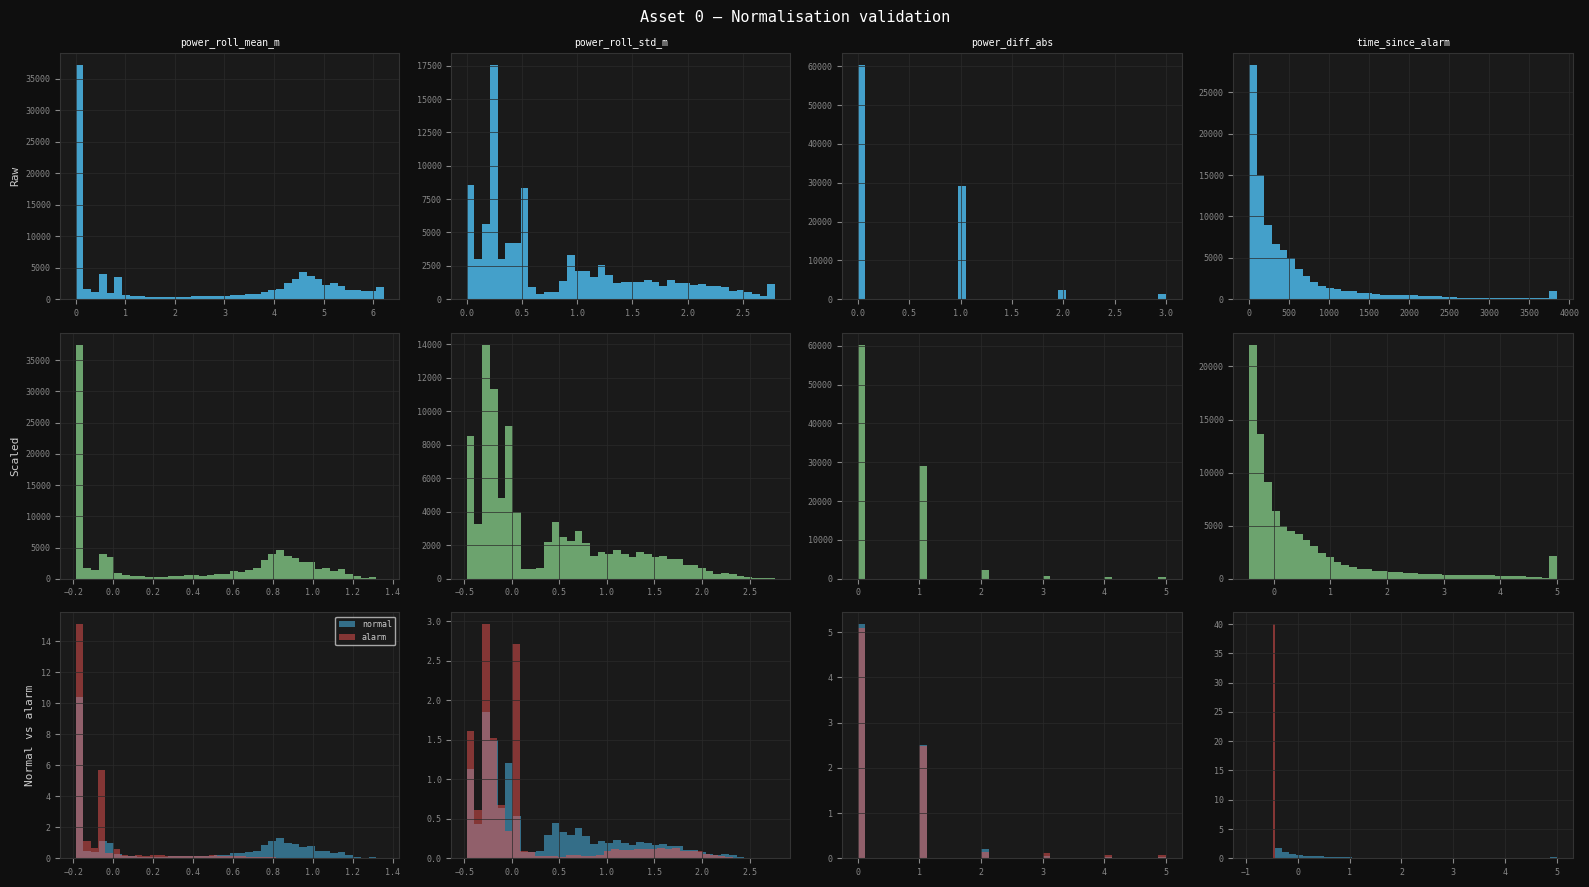

In [30]:
# ── Cell 10: Normalisation validation ────────────────────────────────────────
# FIX: only 4 features now so layout is 3x4
fig, axes = plt.subplots(3, len(FEATURE_COLS_IF), figsize=(16, 9))
fig.suptitle('Asset 0 — Normalisation validation', fontsize=11, color='white')

# Need all-data scaled for overlay
scaler_tmp = RobustScaler().fit(df_normal[FEATURE_COLS_IF])
df_all_scaled_tmp = pd.DataFrame(
    scaler_tmp.transform(df2[FEATURE_COLS_IF]),
    columns=FEATURE_COLS_IF
)
df_all_scaled_tmp['alarm'] = df2['alarm'].values

for i, feat in enumerate(FEATURE_COLS_IF):
    raw    = df_normal[feat]
    scaled = df_normal_scaled[feat]

    axes[0, i].hist(raw.clip(upper=raw.quantile(0.99)), bins=40,
                    color='#4fc3f7', alpha=0.8, edgecolor='none')
    axes[0, i].set_title(feat, fontsize=7)
    if i == 0: axes[0, i].set_ylabel('Raw', fontsize=8)

    axes[1, i].hist(scaled.clip(-5, 5), bins=40,
                    color='#81c784', alpha=0.8, edgecolor='none')
    if i == 0: axes[1, i].set_ylabel('Scaled', fontsize=8)

    anom_feat = df_all_scaled_tmp[df_all_scaled_tmp['alarm'] == 1][feat]
    axes[2, i].hist(scaled.clip(-5, 5), bins=40, color='#4fc3f7',
                    alpha=0.5, density=True, label='normal')
    axes[2, i].hist(anom_feat.clip(-5, 5), bins=40, color='#ef5350',
                    alpha=0.5, density=True, label='alarm')
    if i == 0:
        axes[2, i].set_ylabel('Normal vs alarm', fontsize=8)
        axes[2, i].legend(fontsize=6)

    for row in range(3):
        axes[row, i].grid(True)
        axes[row, i].tick_params(labelsize=6)

plt.tight_layout()
plt.savefig('05_normalisation_validation.png', dpi=150, bbox_inches='tight')
plt.show()

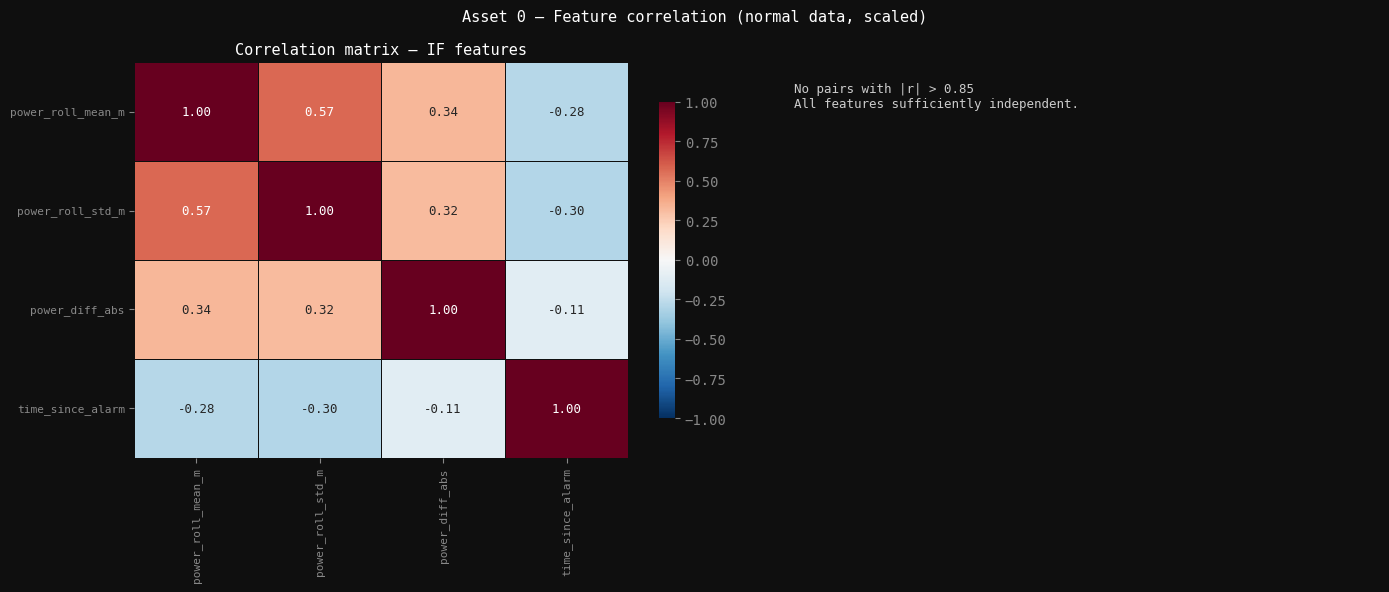

High-corr pairs: 0


In [31]:
# ── Cell 11: Correlation heatmap ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Asset 0 — Feature correlation (normal data, scaled)', fontsize=11, color='white')

corr = df_normal_scaled.corr()

sns.heatmap(corr, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#0f0f0f',
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation matrix — IF features')
axes[0].tick_params(labelsize=8)

high_corr_pairs = []
for a in range(len(FEATURE_COLS_IF)):
    for b in range(a+1, len(FEATURE_COLS_IF)):
        r = corr.iloc[a, b]
        if abs(r) > 0.85:
            high_corr_pairs.append((FEATURE_COLS_IF[a], FEATURE_COLS_IF[b], round(r, 3)))

axes[1].axis('off')
if high_corr_pairs:
    text = "High-correlation pairs (|r|>0.85):\n\n"
    for a, b, r in high_corr_pairs:
        text += f"  {a}\n  {b}\n  r={r}\n\n"
else:
    text = "No pairs with |r| > 0.85\nAll features sufficiently independent."
axes[1].text(0.05, 0.95, text, transform=axes[1].transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             color='#cccccc')

plt.tight_layout()
plt.savefig('06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"High-corr pairs: {len(high_corr_pairs)}")

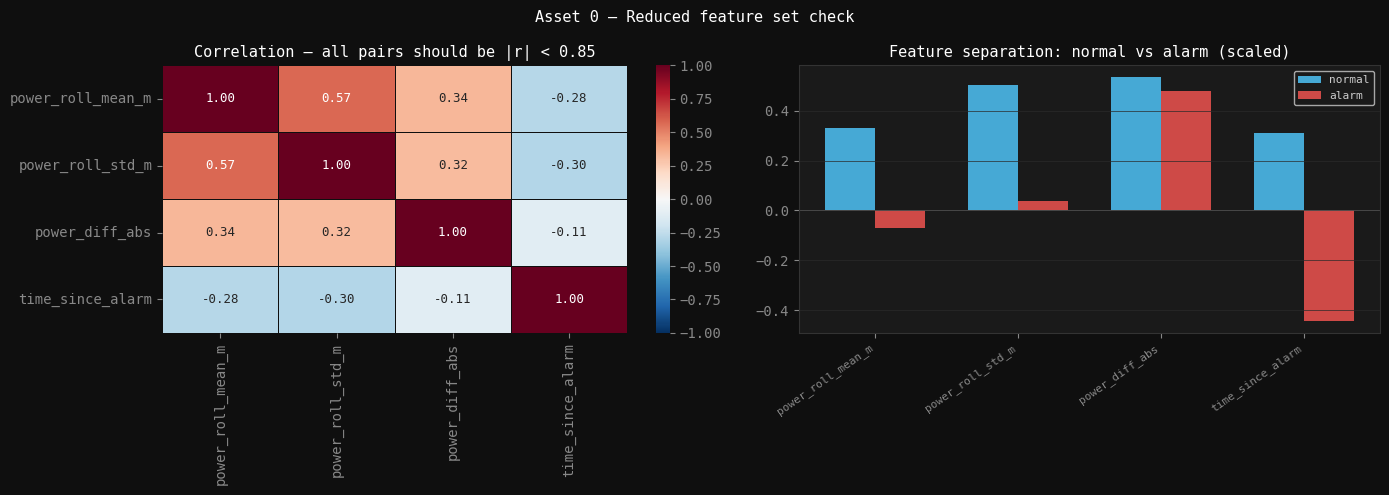

In [32]:
# ── Cell 12 / Cell 13: Feature separation (Cohen's d bar chart) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Asset 0 — Reduced feature set check', fontsize=11, color='white')

sns.heatmap(corr, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#0f0f0f')
axes[0].set_title('Correlation — all pairs should be |r| < 0.85')

axes[1].set_title('Feature separation: normal vs alarm (scaled)')
normal_means  = df_all_scaled_tmp[df_all_scaled_tmp['alarm'] == 0][FEATURE_COLS_IF].mean()
anomaly_means = df_all_scaled_tmp[df_all_scaled_tmp['alarm'] == 1][FEATURE_COLS_IF].mean()

x = np.arange(len(FEATURE_COLS_IF))
w = 0.35
axes[1].bar(x - w/2, normal_means,  width=w, color='#4fc3f7', alpha=0.85, label='normal')
axes[1].bar(x + w/2, anomaly_means, width=w, color='#ef5350', alpha=0.85, label='alarm')
axes[1].set_xticks(x)
axes[1].set_xticklabels(FEATURE_COLS_IF, rotation=35, ha='right', fontsize=8)
axes[1].axhline(0, color='#555', linewidth=0.5)
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('07_feature_separation.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# ── Cell 18 (REVISED): Re-scale final feature set, compute contamination ──────
# FIX: clean single-pass scaling with no shape mismatches.
import joblib

df_normal_running = df2[
    (df2['status'].isin([1.0, 2.0])) &
    (df2['alarm'] == 0) &
    (df2['pre_alarm'] == 0) &
    (df2['is_on'] == 1)
].copy().reset_index(drop=True)

scaler_if = RobustScaler()
X_train_if = scaler_if.fit_transform(df_normal_running[FEATURE_COLS_IF])
X_all_if   = scaler_if.transform(df2[FEATURE_COLS_IF])

df_train_if = pd.DataFrame(X_train_if, columns=FEATURE_COLS_IF)

df_scored = pd.DataFrame(X_all_if, columns=FEATURE_COLS_IF)
df_scored['ts']               = df2['ts'].values
df_scored['status']           = df2['status'].values
df_scored['alarm']            = df2['alarm'].values
df_scored['pre_alarm']        = df2['pre_alarm'].values
df_scored['is_on']            = df2['is_on'].values
df_scored['session_id']       = df2['session_id'].values
df_scored['alarm_roll_m']     = df2['alarm_roll_m'].values
df_scored['cycle_roll_mean_l']= df2['cycle_roll_mean_l'].values

# Contamination on running rows only
df_running = df2[df2['is_on'] == 1]
contamination = (
    (df_running['status'] == 3.0) |
    (df_running['alarm'] == 1) |
    (df_running['pre_alarm'] == 1)
).mean()

print(f"Training rows (normal + running) : {len(df_train_if):,}")
print(f"Scored rows (full timeline)      : {len(df_scored):,}")
print(f"Contamination (running rows)     : {contamination:.4f}  ({contamination:.1%})")
print(f"Any NaN in train                 : {df_train_if.isnull().any().any()}")
print(f"Shape match: train={df_train_if.shape}, scored={df_scored[FEATURE_COLS_IF].shape}")

joblib.dump(scaler_if, 'asset0_scaler_if_v3.pkl')
df_train_if.to_parquet('asset0_train_if_v3.parquet', index=False)
df_scored.to_parquet('asset0_scored_ready_v3.parquet', index=False)
print("\n✓  Saved. Ready to build model.")
print(f"   Contamination to use: {contamination:.3f}")

Training rows (normal + running) : 48,528
Scored rows (full timeline)      : 168,217
Contamination (running rows)     : 0.4115  (41.2%)
Any NaN in train                 : False
Shape match: train=(48528, 4), scored=(168217, 4)

✓  Saved. Ready to build model.
   Contamination to use: 0.412


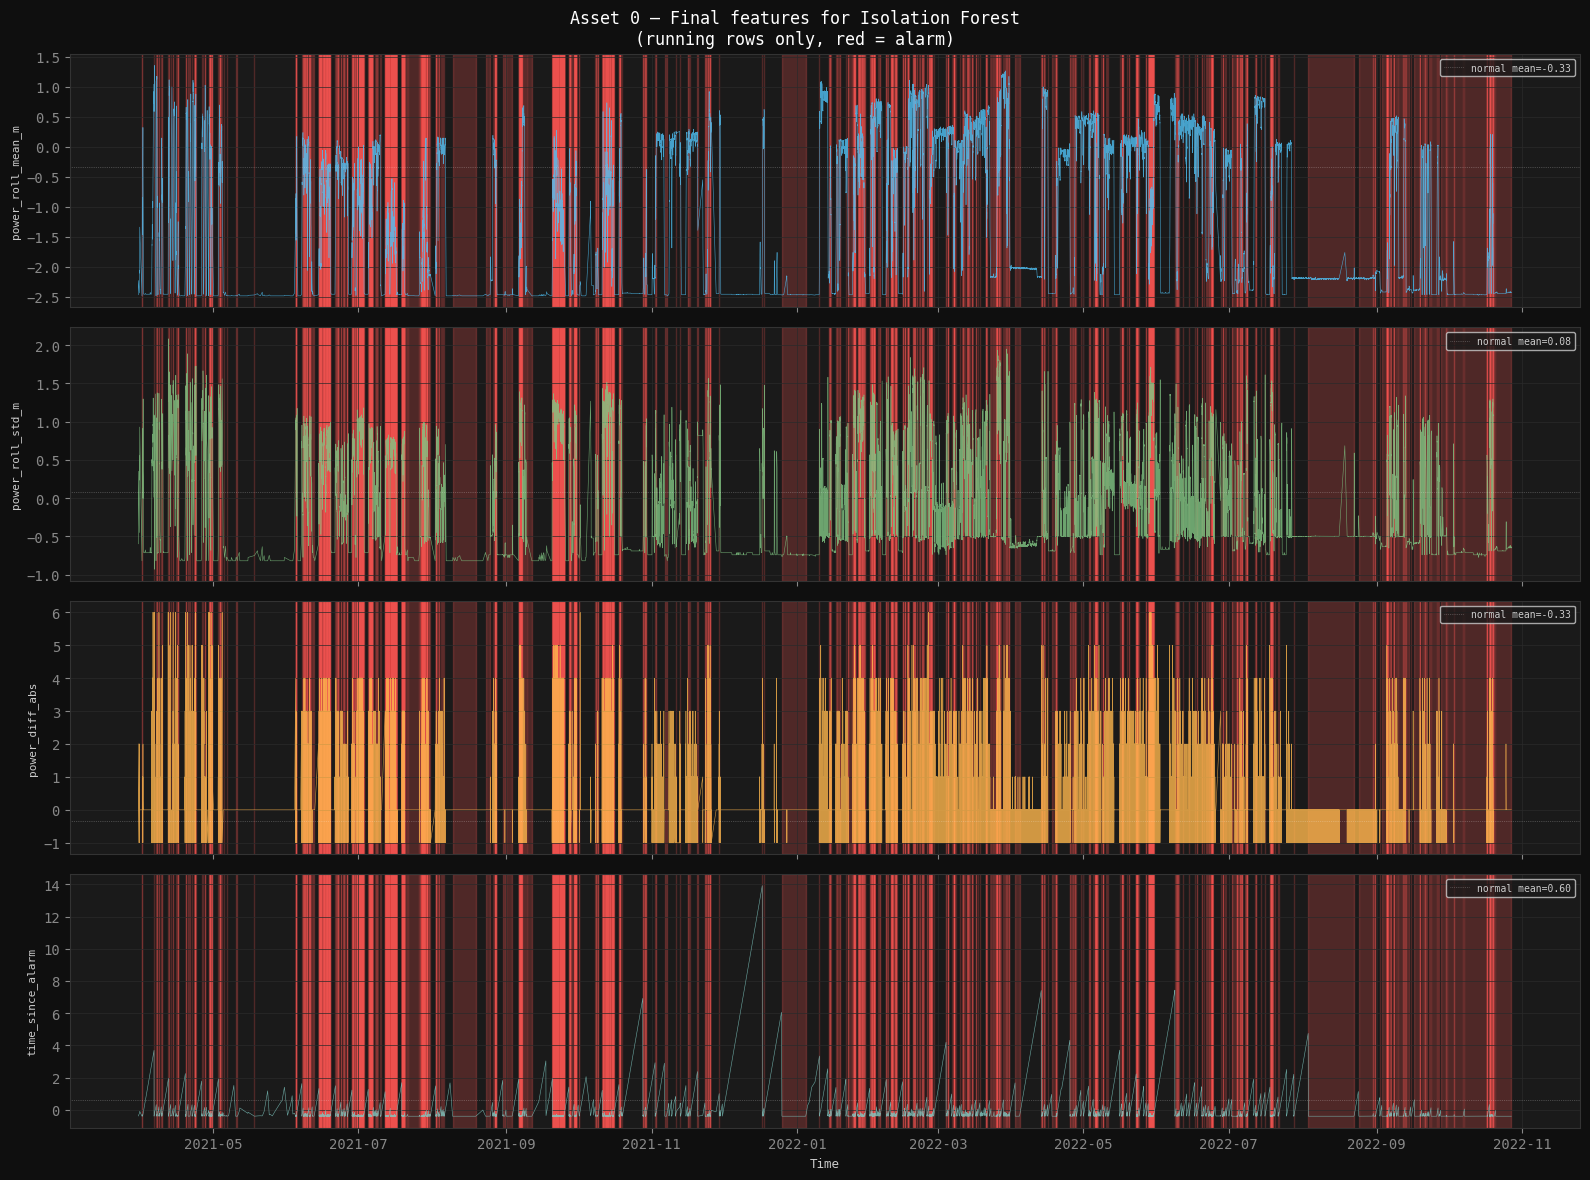

── Feature separation (Cohen's d) ──
  power_roll_mean_m          d=1.681  ★ strong
  power_roll_std_m           d=0.495  ~ moderate
  power_diff_abs             d=0.341  ~ moderate
  time_since_alarm           d=0.768  ★ strong


In [34]:
# ── Cell 19: Final feature visualisation (running rows only) ──────────────────
fig, axes = plt.subplots(len(FEATURE_COLS_IF), 1, figsize=(16, 12), sharex=True)
fig.suptitle('Asset 0 — Final features for Isolation Forest\n(running rows only, red = alarm)',
             fontsize=12, color='white')

colors = ['#4fc3f7', '#81c784', '#ffb74d', '#80cbc4']
df_plot = df_scored[df_scored['is_on'] == 1].copy()

for ax, feat, color in zip(axes, FEATURE_COLS_IF, colors):
    ax.plot(df_plot['ts'], df_plot[feat], color=color, linewidth=0.4, alpha=0.8)
    mask = df_plot['alarm'] == 1
    changes = mask.ne(mask.shift()).cumsum()
    for _, grp in df_plot[mask].groupby(changes[mask]):
        ax.axvspan(grp['ts'].iloc[0], grp['ts'].iloc[-1],
                   alpha=0.25, color='#ef5350', zorder=0)
    normal_mean = df_train_if[feat].mean()
    ax.axhline(normal_mean, color='#ffffff', linewidth=0.5, linestyle=':',
               alpha=0.4, label=f'normal mean={normal_mean:.2f}')
    ax.set_ylabel(feat, fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.savefig('09_final_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Feature separation (Cohen's d) ──")
for feat in FEATURE_COLS_IF:
    normal_vals = df_scored[(df_scored['alarm']==0) & (df_scored['is_on']==1)][feat]
    alarm_vals  = df_scored[(df_scored['alarm']==1) & (df_scored['is_on']==1)][feat]
    pooled_std  = np.sqrt((normal_vals.std()**2 + alarm_vals.std()**2) / 2)
    d = abs(normal_vals.mean() - alarm_vals.mean()) / (pooled_std + 1e-9)
    tag = '★ strong' if d > 0.5 else '~ moderate' if d > 0.2 else '✗ weak'
    print(f"  {feat:25s}  d={d:.3f}  {tag}")

In [35]:
# ── Cell 20: Isolation Forest — fit & score ───────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report

RANDOM_STATE = 42
CONTAMINATION = float(contamination)  # computed above

iso_forest = IsolationForest(
    n_estimators  = 300,
    contamination = CONTAMINATION,
    max_samples   = 'auto',
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
)
iso_forest.fit(df_train_if[FEATURE_COLS_IF])
print("✓  Isolation Forest fitted")

raw_scores  = iso_forest.decision_function(df_scored[FEATURE_COLS_IF])
predictions = iso_forest.predict(df_scored[FEATURE_COLS_IF])

df_scored['if_raw_score']  = raw_scores
df_scored['if_prediction'] = predictions

print(f"\n── Raw score distribution ──")
print(pd.Series(raw_scores).describe().round(4))
print(f"\nPredicted anomalies : {(predictions==-1).sum():,}  ({(predictions==-1).mean():.1%})")
print(f"Predicted normal    : {(predictions== 1).sum():,}  ({(predictions== 1).mean():.1%})")

✓  Isolation Forest fitted

── Raw score distribution ──
count    168217.0000
mean         -0.0533
std           0.0674
min          -0.2858
25%          -0.1066
50%          -0.0605
75%          -0.0002
max           0.0779
dtype: float64

Predicted anomalies : 126,252  (75.1%)
Predicted normal    : 41,965  (24.9%)


In [36]:
# ── Cell 21: Health score generation ─────────────────────────────────────────
s      = df_scored['if_raw_score']
s_norm = (s - s.min()) / (s.max() - s.min())

df_scored['health_raw']    = (s_norm * 100).round(2)
df_scored['health_smooth'] = (
    df_scored['health_raw']
    .ewm(span=30, adjust=False)
    .mean()
    .round(2)
)

def assign_band(score):
    if score >= 75:  return 'healthy'
    elif score >= 50: return 'degrading'
    else:             return 'alert'

df_scored['health_band'] = df_scored['health_smooth'].apply(assign_band)

print("── Health score stats ──")
print(df_scored[['health_raw','health_smooth']].describe().round(2))
print(f"\nBand distribution:\n{df_scored['health_band'].value_counts()}")
print(f"\nHealth score — alarm rows (mean)  : {df_scored[df_scored['alarm']==1]['health_smooth'].mean():.1f}")
print(f"Health score — normal rows (mean) : {df_scored[df_scored['alarm']==0]['health_smooth'].mean():.1f}")

── Health score stats ──
       health_raw  health_smooth
count   168217.00      168217.00
mean        63.92          63.92
std         18.53          16.58
min          0.00          11.43
25%         49.27          50.25
50%         61.96          61.63
75%         78.53          76.66
max        100.00          97.42

Band distribution:
health_band
degrading    82969
healthy      45101
alert        40147
Name: count, dtype: int64

Health score — alarm rows (mean)  : 57.7
Health score — normal rows (mean) : 65.8


In [37]:
# ── Cell 22 (REVISED): XGBoost — predict pre_alarm ───────────────────────────
# FIX: target is pre_alarm (predict BEFORE the event), not alarm (during it).
# FIX: scale_pos_weight guard against zero division.
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler as RS

df2_xgb = df2.copy()
df2_xgb['health_smooth'] = df_scored['health_smooth'].values
df2_xgb['if_raw_score']  = df_scored['if_raw_score'].values

FEATURE_COLS_XGB_FINAL = [
    'power_roll_mean_m',
    'power_roll_std_m',
    'power_diff_abs',
    'time_since_alarm',
    'cycle_roll_mean_l',
    'is_on',
    'alarm_roll_m',
    'health_smooth',
    'if_raw_score',
]

df_xgb = df2_xgb[FEATURE_COLS_XGB_FINAL + ['pre_alarm', 'alarm']].dropna().reset_index(drop=True)

X = df_xgb[FEATURE_COLS_XGB_FINAL]
y = df_xgb['pre_alarm']  # predict pre-alarm, not alarm itself

scaler_xgb = RS()
X_scaled   = scaler_xgb.fit_transform(X)

tscv   = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X_scaled))
train_idx, test_idx = splits[-1]

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y.iloc[train_idx],   y.iloc[test_idx]

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Pre-alarm rate train : {y_train.mean():.4f}")
print(f"scale_pos_weight     : {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators          = 400,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'aucpr',
    early_stopping_rounds = 30,
    random_state          = RANDOM_STATE,
    n_jobs                = -1,
    verbosity             = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

print(f"\n✓  XGBoost fitted  (best iteration: {xgb_model.best_iteration})")

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"\n── Test set evaluation (target = pre_alarm) ──")
print(classification_report(y_test, y_pred,
      target_names=['not pre-alarm', 'pre-alarm'], digits=3))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}")

joblib.dump(xgb_model,  'asset0_xgb_model_v2.pkl')
joblib.dump(scaler_xgb, 'asset0_scaler_xgb_v2.pkl')

Train: 132,868  Test: 26,573
Pre-alarm rate train : 0.3820
scale_pos_weight     : 1.62

✓  XGBoost fitted  (best iteration: 7)

── Test set evaluation (target = pre_alarm) ──
               precision    recall  f1-score   support

not pre-alarm      0.863     0.886     0.875      7425
    pre-alarm      0.955     0.946     0.950     19148

     accuracy                          0.929     26573
    macro avg      0.909     0.916     0.913     26573
 weighted avg      0.930     0.929     0.929     26573

ROC-AUC : 0.9746


['asset0_scaler_xgb_v2.pkl']

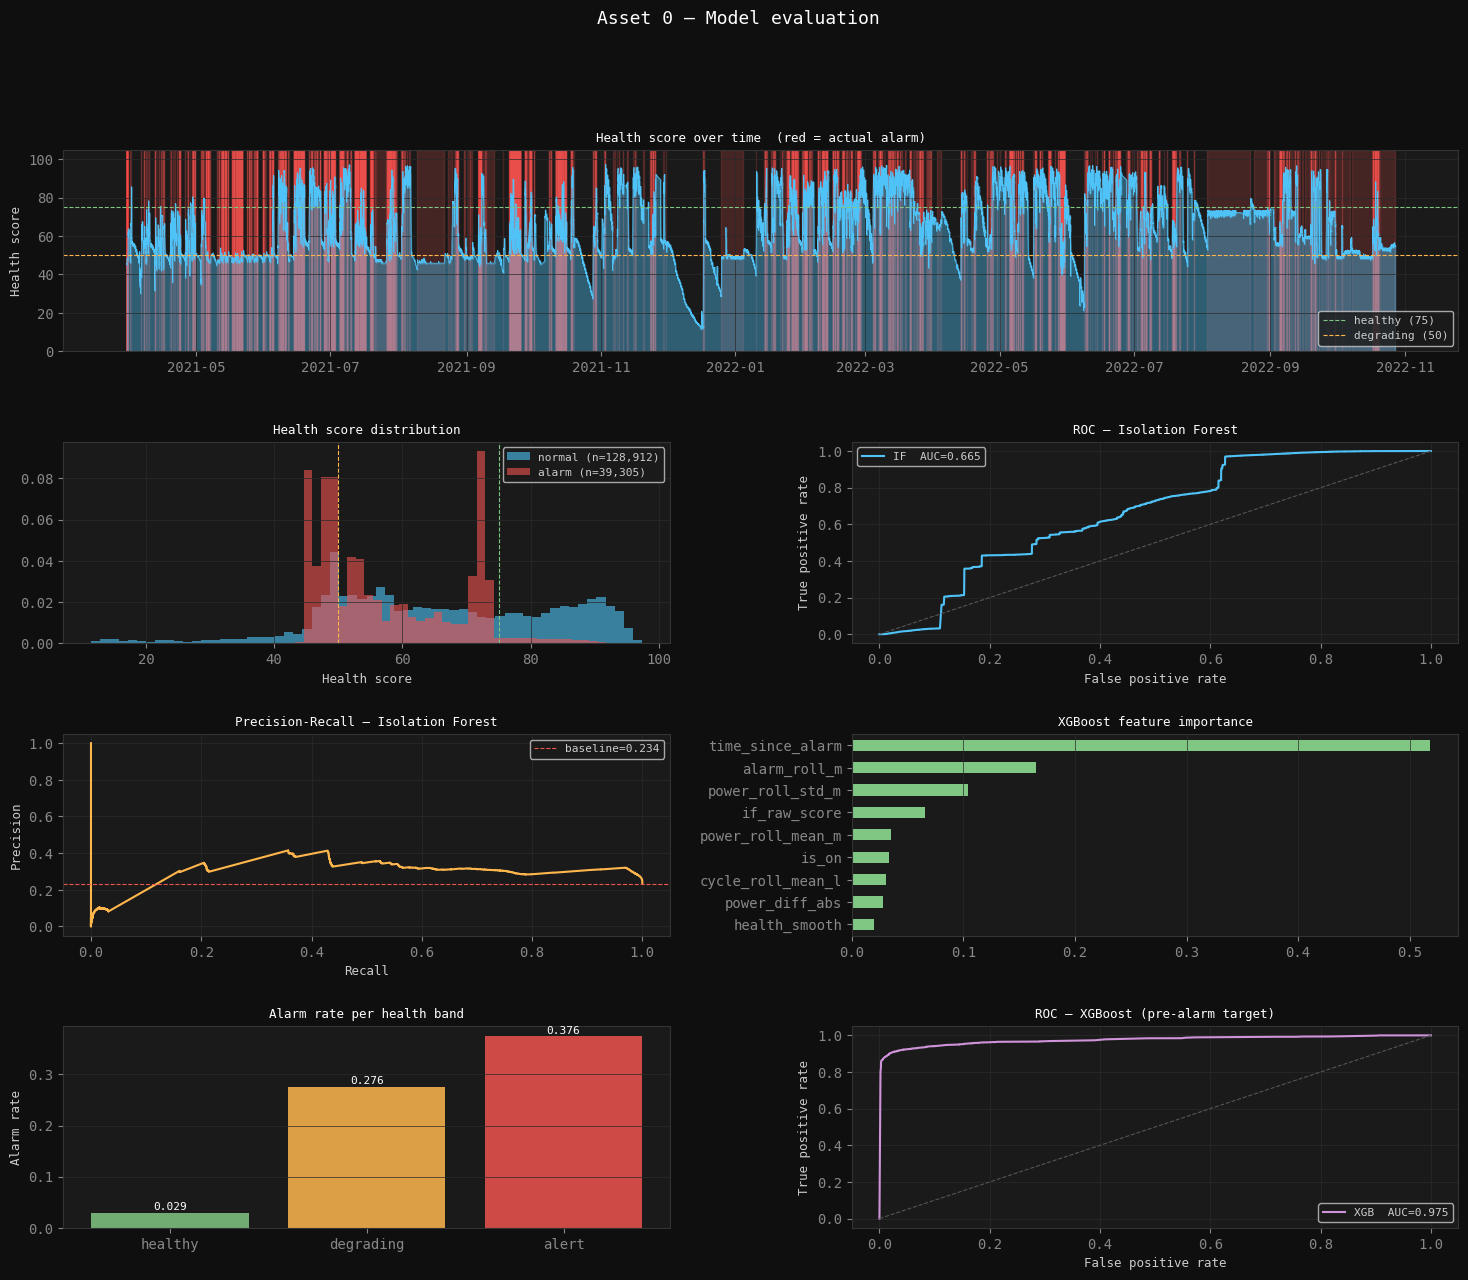

IF  AUC : 0.6653
XGB AUC : 0.9746


In [38]:
# ── Cell 23: Model evaluation plots ──────────────────────────────────────────
from sklearn.metrics import roc_curve

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('Asset 0 — Model evaluation', fontsize=13, color='white')

# 1. Health score over time
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(df_scored['ts'], df_scored['health_smooth'],
                 alpha=0.4, color='#4fc3f7')
ax1.plot(df_scored['ts'], df_scored['health_smooth'],
         color='#4fc3f7', linewidth=0.5)
ax1.axhline(75, color='#81c784', linewidth=0.8, linestyle='--', label='healthy (75)')
ax1.axhline(50, color='#ffb74d', linewidth=0.8, linestyle='--', label='degrading (50)')
mask = df_scored['alarm'] == 1
for _, grp in df_scored[mask].groupby((~mask).cumsum()):
    ax1.axvspan(grp['ts'].iloc[0], grp['ts'].iloc[-1],
                alpha=0.2, color='#ef5350', zorder=0)
ax1.set_title('Health score over time  (red = actual alarm)', fontsize=9)
ax1.set_ylabel('Health score')
ax1.legend(fontsize=8, loc='lower right')
ax1.set_ylim(0, 105)
ax1.grid(True)

# 2. Score distribution
ax2 = fig.add_subplot(gs[1, 0])
normal_scores = df_scored[df_scored['alarm'] == 0]['health_smooth']
alarm_scores  = df_scored[df_scored['alarm'] == 1]['health_smooth']
ax2.hist(normal_scores, bins=60, color='#4fc3f7', alpha=0.6,
         density=True, label=f'normal (n={len(normal_scores):,})')
ax2.hist(alarm_scores,  bins=60, color='#ef5350', alpha=0.6,
         density=True, label=f'alarm (n={len(alarm_scores):,})')
ax2.axvline(75, color='#81c784', linestyle='--', linewidth=0.8)
ax2.axvline(50, color='#ffb74d', linestyle='--', linewidth=0.8)
ax2.set_title('Health score distribution', fontsize=9)
ax2.set_xlabel('Health score')
ax2.legend(fontsize=8)
ax2.grid(True)

# 3. ROC — IF
ax3 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(df_scored['alarm'], -df_scored['if_raw_score'])
auc_if = roc_auc_score(df_scored['alarm'], -df_scored['if_raw_score'])
ax3.plot(fpr, tpr, color='#4fc3f7', linewidth=1.5, label=f'IF  AUC={auc_if:.3f}')
ax3.plot([0,1],[0,1], color='#555', linewidth=0.8, linestyle='--')
ax3.set_title('ROC — Isolation Forest', fontsize=9)
ax3.set_xlabel('False positive rate')
ax3.set_ylabel('True positive rate')
ax3.legend(fontsize=8)
ax3.grid(True)

# 4. Precision-Recall — IF
ax4 = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(df_scored['alarm'], -df_scored['if_raw_score'])
ax4.plot(rec, prec, color='#ffb74d', linewidth=1.5)
ax4.axhline(df_scored['alarm'].mean(), color='#ef5350', linewidth=0.8, linestyle='--',
            label=f'baseline={df_scored["alarm"].mean():.3f}')
ax4.set_title('Precision-Recall — Isolation Forest', fontsize=9)
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.legend(fontsize=8)
ax4.grid(True)

# 5. XGB feature importance
ax5 = fig.add_subplot(gs[2, 1])
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS_XGB_FINAL)
importances.sort_values().plot(kind='barh', ax=ax5, color='#81c784', edgecolor='none')
ax5.set_title('XGBoost feature importance', fontsize=9)
ax5.grid(True, axis='x')

# 6. Alarm rate per health band
ax6 = fig.add_subplot(gs[3, 0])
band_alarm = df_scored.groupby('health_band')['alarm'].mean().reindex(
    ['healthy', 'degrading', 'alert'])
colors_bar = ['#81c784', '#ffb74d', '#ef5350']
ax6.bar(band_alarm.index, band_alarm.values, color=colors_bar, edgecolor='none', alpha=0.85)
ax6.set_title('Alarm rate per health band', fontsize=9)
ax6.set_ylabel('Alarm rate')
ax6.grid(True, axis='y')
for i, (band, val) in enumerate(band_alarm.items()):
    if not np.isnan(val):
        ax6.text(i, val + 0.005, f'{val:.3f}', ha='center', fontsize=8, color='white')

# 7. ROC — XGB
ax7 = fig.add_subplot(gs[3, 1])
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob)
auc_xgb = roc_auc_score(y_test, y_prob)
ax7.plot(fpr_x, tpr_x, color='#ce93d8', linewidth=1.5,
         label=f'XGB  AUC={auc_xgb:.3f}')
ax7.plot([0,1],[0,1], color='#555', linewidth=0.8, linestyle='--')
ax7.set_title('ROC — XGBoost (pre-alarm target)', fontsize=9)
ax7.set_xlabel('False positive rate')
ax7.set_ylabel('True positive rate')
ax7.legend(fontsize=8)
ax7.grid(True)

plt.savefig('10_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IF  AUC : {auc_if:.4f}")
print(f"XGB AUC : {auc_xgb:.4f}")

In [39]:
# ── Cell 24: Attach XGB probabilities & combined alert ───────────────────────
# FIX: align indices carefully to avoid shape mismatch.

df2_score = df2.copy()
df2_score['health_smooth'] = df_scored['health_smooth'].values
df2_score['if_raw_score']  = df_scored['if_raw_score'].values

# Build XGB feature matrix for full timeline
X_full = df2_score[FEATURE_COLS_XGB_FINAL].copy()
valid_mask = X_full.notna().all(axis=1)
X_full_clean = X_full[valid_mask]
X_full_scaled = scaler_xgb.transform(X_full_clean)

xgb_probs_full = xgb_model.predict_proba(X_full_scaled)[:, 1]

df_scored['xgb_pre_alarm_prob'] = np.nan
df_scored.loc[valid_mask.values, 'xgb_pre_alarm_prob'] = xgb_probs_full

# Combined alert: IF says alert AND XGB pre-alarm probability high
df_scored['combined_alert'] = (
    (df_scored['health_band'] == 'alert') &
    (df_scored['xgb_pre_alarm_prob'] > 0.5)
).astype(int)

df_scored.to_parquet('asset0_final_scored.parquet', index=False)

print("═" * 55)
print("  Asset 0 — Final model summary")
print("═" * 55)
print(f"  IF  AUC (vs alarm label)  : {auc_if:.4f}")
print(f"  XGB AUC (pre-alarm test)  : {auc_xgb:.4f}")
print(f"  Health mean — normal      : {df_scored[df_scored['alarm']==0]['health_smooth'].mean():.1f}")
print(f"  Health mean — alarm       : {df_scored[df_scored['alarm']==1]['health_smooth'].mean():.1f}")
print(f"  Combined alerts fired     : {df_scored['combined_alert'].sum():,}")
print(f"  Actual alarms in data     : {df_scored['alarm'].sum():,}")
print(f"\n  Saved → asset0_final_scored.parquet")
print("═" * 55)

═══════════════════════════════════════════════════════
  Asset 0 — Final model summary
═══════════════════════════════════════════════════════
  IF  AUC (vs alarm label)  : 0.6653
  XGB AUC (pre-alarm test)  : 0.9746
  Health mean — normal      : 65.8
  Health mean — alarm       : 57.7
  Combined alerts fired     : 17,202
  Actual alarms in data     : 39,305

  Saved → asset0_final_scored.parquet
═══════════════════════════════════════════════════════


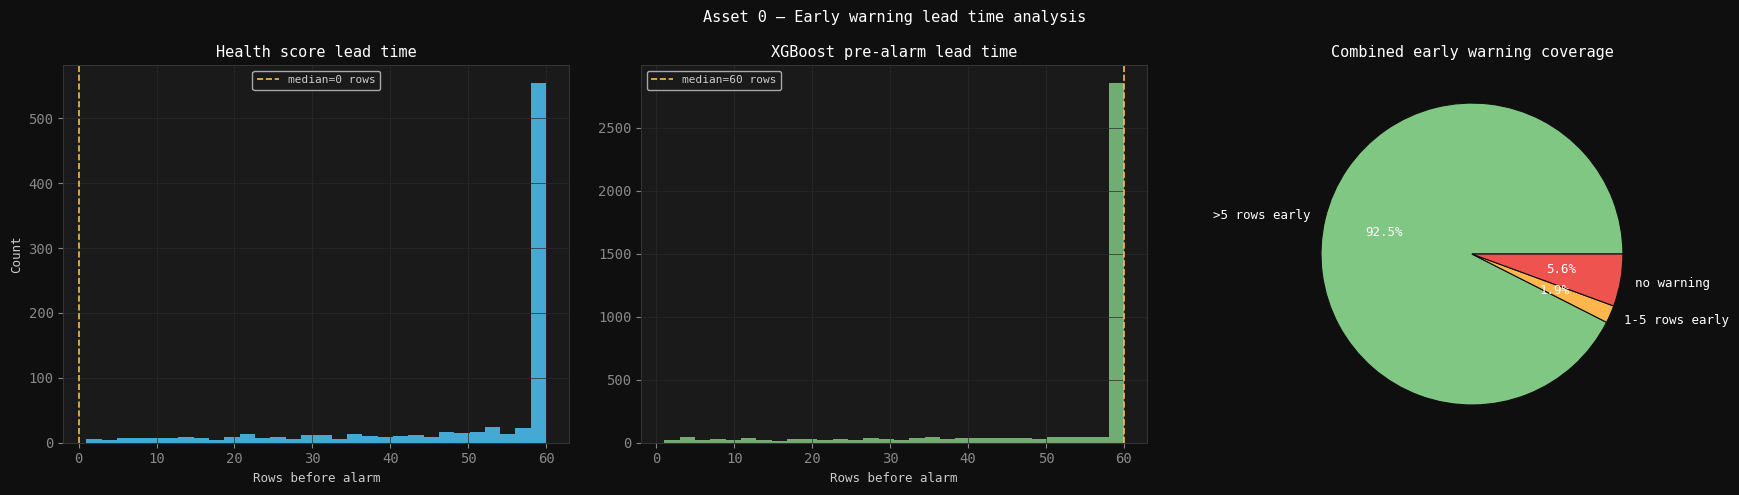

Total alarm events
  Health score: >0 warning=21.0%  >5 rows=20.7%  median=0
  XGB pre-alarm:>0 warning=92.7%  >5 rows=90.8%  median=60
  Combined:     >0 warning=94.4%  >5 rows=92.5%  median=60


In [40]:
# ── Cell 25: Lead time analysis ───────────────────────────────────────────────
# FIX: uses xgb_pre_alarm_prob > 0.5 as the early-warning trigger (not just health score)
# so we can measure genuine pre-event detection.

ALERT_THRESHOLD   = 50
XGB_PROB_THRESHOLD = 0.5
LOOKBACK = 60

# First row of each alarm burst
alarm_mask   = df_scored['alarm'] == 1
alarm_starts = df_scored[
    alarm_mask & (~alarm_mask.shift(1, fill_value=False))
].copy()

lead_times_health = []
lead_times_xgb    = []

for idx in alarm_starts.index:
    start  = max(0, idx - LOOKBACK)
    window = df_scored.loc[start:idx]

    # Health-score early warning
    crossed_h = window[window['health_smooth'] < ALERT_THRESHOLD]
    lead_h = (idx - crossed_h.index[0]) if len(crossed_h) > 0 else 0
    lead_times_health.append(lead_h)

    # XGB early warning
    crossed_x = window[window['xgb_pre_alarm_prob'] > XGB_PROB_THRESHOLD]
    lead_x = (idx - crossed_x.index[0]) if len(crossed_x) > 0 else 0
    lead_times_xgb.append(lead_x)

lh = pd.Series(lead_times_health)
lx = pd.Series(lead_times_xgb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Asset 0 — Early warning lead time analysis', fontsize=11, color='white')

# Health score lead time histogram
axes[0].hist(lh[lh > 0], bins=30, color='#4fc3f7', edgecolor='none', alpha=0.85)
axes[0].axvline(lh.median(), color='#ffb74d', linewidth=1.2, linestyle='--',
                label=f'median={lh.median():.0f} rows')
axes[0].set_title('Health score lead time')
axes[0].set_xlabel('Rows before alarm')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# XGB lead time histogram
axes[1].hist(lx[lx > 0], bins=30, color='#81c784', edgecolor='none', alpha=0.85)
axes[1].axvline(lx.median(), color='#ffb74d', linewidth=1.2, linestyle='--',
                label=f'median={lx.median():.0f} rows')
axes[1].set_title('XGBoost pre-alarm lead time')
axes[1].set_xlabel('Rows before alarm')
axes[1].legend(fontsize=8)
axes[1].grid(True)

# Coverage pie
combined_lead = pd.Series(np.maximum(lh.values, lx.values))
axes[2].pie(
    [
        (combined_lead > 5).sum(),
        ((combined_lead > 0) & (combined_lead <= 5)).sum(),
        (combined_lead == 0).sum()
    ],
    labels=['>5 rows early', '1-5 rows early', 'no warning'],
    colors=['#81c784', '#ffb74d', '#ef5350'],
    autopct='%1.1f%%',
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 0.8}
)
axes[2].set_title('Combined early warning coverage')

plt.tight_layout()
plt.savefig('11_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total alarm events")
print(f"  Health score: >0 warning={( lh>0).mean():.1%}  >5 rows={( lh>5).mean():.1%}  median={lh.median():.0f}")
print(f"  XGB pre-alarm:>0 warning={( lx>0).mean():.1%}  >5 rows={( lx>5).mean():.1%}  median={lx.median():.0f}")
print(f"  Combined:     >0 warning={(combined_lead>0).mean():.1%}  >5 rows={(combined_lead>5).mean():.1%}  median={combined_lead.median():.0f}")

In [41]:
# ── Cell 26: Generalised per-asset pipeline function ─────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import joblib
import os

def run_asset_pipeline(df_raw, asset_id, output_dir='/kaggle/working/results', lookahead=30,
                       w_medium=60, w_long=180, random_state=42, verbose=True):
    """
    Full health monitoring pipeline for a single asset.
    
    Parameters
    ----------
    df_raw      : full raw DataFrame (all assets)
    asset_id    : int, the asset to process
    output_dir  : where to save models and scored data
    lookahead   : rows ahead to flag as pre_alarm
    w_medium    : rolling window (medium)
    w_long      : rolling window (long)
    
    Returns
    -------
    dict with keys:
        df_scored       - full scored timeline
        df_train_if     - IF training matrix
        scaler_if       - fitted RobustScaler
        iso_forest      - fitted IsolationForest
        xgb_model       - fitted XGBClassifier
        scaler_xgb      - fitted RobustScaler for XGB
        metrics         - dict of evaluation metrics
        contamination   - float used for IF
        feature_cols_if - list
        feature_cols_xgb- list
    """
    os.makedirs(output_dir, exist_ok=True)
    tag = f"asset{asset_id}"
    if verbose: print(f"\n{'='*55}\n  Processing {tag.upper()}\n{'='*55}")

    # ── 1. Filter & basic prep ────────────────────────────────────────────────
    df = df_raw[df_raw['asset'] == asset_id].copy().reset_index(drop=True)
    df['ts'] = pd.to_datetime(df['ts'], utc=True) if df['ts'].dtype == object else df['ts']
    df = df.sort_values('ts').reset_index(drop=True)
    
    if verbose:
        print(f"  Rows            : {len(df):,}")
        print(f"  Date range      : {df['ts'].min().date()} → {df['ts'].max().date()}")
        print(f"  Status counts   : {df['status'].value_counts().to_dict()}")
        print(f"  Alarm rate      : {df['alarm'].mean():.4f}")

    # ── 2. Clip outliers ──────────────────────────────────────────────────────
    clip_features = ['power_avg', 'cycle_time', 'items', 'status_time']
    clip_thresholds = {}
    for feat in clip_features:
        p25, p75, p99 = df[feat].quantile([0.25, 0.75, 0.99])
        iqr   = p75 - p25
        upper = min(p75 + 3.0 * iqr, p99)
        clip_thresholds[feat] = upper
        df[feat] = df[feat].clip(lower=0.0, upper=upper)

    # ── 3. Derived columns ────────────────────────────────────────────────────
    df['ts_diff']      = df['ts'].diff().dt.total_seconds()
    df['is_on']        = (df['power_avg'] > 0).astype(int)
    df['status']       = df['status'].ffill()
    df['session_break']= (df['ts_diff'] > 300).fillna(False).astype(int)
    df['session_id']   = df['session_break'].cumsum()

    # ── 4. Rolling features (session-aware) ───────────────────────────────────
    def rolling_sess(series, session_ids, window, func='mean'):
        out = pd.Series(index=series.index, dtype=float)
        for sid, idx in series.groupby(session_ids).groups.items():
            s = series.loc[idx]
            mp = max(1 if func=='mean' else 2, window // 4)
            if func == 'mean':
                out.loc[idx] = s.rolling(window, min_periods=mp).mean()
            elif func == 'std':
                out.loc[idx] = s.rolling(window, min_periods=mp).std()
        return out

    sid = df['session_id']
    df['power_roll_mean_m'] = rolling_sess(df['power_avg'],  sid, w_medium, 'mean')
    df['power_roll_std_m']  = rolling_sess(df['power_avg'],  sid, w_medium, 'std')
    df['power_diff_abs']    = df['power_avg'].diff().abs().fillna(0)
    df['cycle_roll_mean_l'] = rolling_sess(df['cycle_time'], sid, w_long,   'mean')
    df['alarm_roll_m']      = rolling_sess(df['alarm'].astype(float), sid, w_medium, 'mean')

    # ── 5. time_since_alarm (backward, no leakage) ───────────────────────────
    alarm_flag = (df['status'] == 3.0).values
    counter, tsa = 0, []
    for flag in alarm_flag:
        counter = 0 if flag else counter + 1
        tsa.append(counter)
    df['time_since_alarm'] = tsa

    # ── 6. pre_alarm label (forward-looking) ─────────────────────────────────
    s3 = (df['status'] == 3.0).astype(float)
    df['pre_alarm'] = (
        s3.iloc[::-1]
         .rolling(lookahead, min_periods=1).max()
         .iloc[::-1]
         .shift(-1)
         .fillna(0)
         .astype(int)
    )

    # ── 7. Feature definitions ────────────────────────────────────────────────
    FEATURE_COLS_IF = [
        'power_roll_mean_m',
        'power_roll_std_m',
        'power_diff_abs',
        'time_since_alarm',
    ]
    FEATURE_COLS_XGB_FINAL = [
        'power_roll_mean_m',
        'power_roll_std_m',
        'power_diff_abs',
        'time_since_alarm',
        'cycle_roll_mean_l',
        'is_on',
        'alarm_roll_m',
        'health_smooth',    # added after IF scoring
        'if_raw_score',     # added after IF scoring
    ]

    # ── 8. Build clean working df ─────────────────────────────────────────────
    base_cols = list(set(
        FEATURE_COLS_IF +
        ['cycle_roll_mean_l','is_on','alarm_roll_m'] +
        ['ts','status','alarm','session_id','pre_alarm']
    ))
    df2 = df[base_cols].dropna(subset=FEATURE_COLS_IF).reset_index(drop=True)

    # ── 9. Train/normal split ─────────────────────────────────────────────────
    df_normal_running = df2[
        (df2['status'].isin([1.0, 2.0])) &
        (df2['alarm'] == 0) &
        (df2['pre_alarm'] == 0) &
        (df2['is_on'] == 1)
    ].copy().reset_index(drop=True)

    if len(df_normal_running) < 100:
        if verbose: print(f"  WARNING: only {len(df_normal_running)} normal rows — skipping {tag}")
        return None

    # ── 10. Scale IF features ─────────────────────────────────────────────────
    scaler_if   = RobustScaler()
    X_train_if  = scaler_if.fit_transform(df_normal_running[FEATURE_COLS_IF])
    X_all_if    = scaler_if.transform(df2[FEATURE_COLS_IF])
    df_train_if = pd.DataFrame(X_train_if, columns=FEATURE_COLS_IF)

    df_scored = pd.DataFrame(X_all_if, columns=FEATURE_COLS_IF)
    for col in ['ts','status','alarm','pre_alarm','is_on','session_id',
                'alarm_roll_m','cycle_roll_mean_l']:
        df_scored[col] = df2[col].values

    # ── 11. Contamination ─────────────────────────────────────────────────────
    df_running   = df2[df2['is_on'] == 1]
    contamination = (
        (df_running['status'] == 3.0) |
        (df_running['alarm'] == 1) |
        (df_running['pre_alarm'] == 1)
    ).mean()
    contamination = float(np.clip(contamination, 0.01, 0.49))

    if verbose:
        print(f"  Normal running  : {len(df_normal_running):,}")
        print(f"  Contamination   : {contamination:.4f}  ({contamination:.1%})")

    # ── 12. Isolation Forest ──────────────────────────────────────────────────
    iso_forest = IsolationForest(
        n_estimators  = 300,
        contamination = contamination,
        max_samples   = 'auto',
        random_state  = random_state,
        n_jobs        = -1,
    )
    iso_forest.fit(df_train_if[FEATURE_COLS_IF])

    raw_scores  = iso_forest.decision_function(df_scored[FEATURE_COLS_IF])
    predictions = iso_forest.predict(df_scored[FEATURE_COLS_IF])
    df_scored['if_raw_score']  = raw_scores
    df_scored['if_prediction'] = predictions

    # ── 13. Health score ──────────────────────────────────────────────────────
    s      = df_scored['if_raw_score']
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-9)
    df_scored['health_raw']    = (s_norm * 100).round(2)
    df_scored['health_smooth'] = (
        df_scored['health_raw'].ewm(span=30, adjust=False).mean().round(2)
    )

    def assign_band(score):
        if score >= 75:   return 'healthy'
        elif score >= 50: return 'degrading'
        else:             return 'alert'

    df_scored['health_band'] = df_scored['health_smooth'].apply(assign_band)

    # ── 14. XGBoost ───────────────────────────────────────────────────────────
    df2_xgb = df2.copy()
    df2_xgb['health_smooth'] = df_scored['health_smooth'].values
    df2_xgb['if_raw_score']  = df_scored['if_raw_score'].values

    df_xgb = df2_xgb[FEATURE_COLS_XGB_FINAL + ['pre_alarm','alarm']].dropna().reset_index(drop=True)
    
    X   = df_xgb[FEATURE_COLS_XGB_FINAL]
    y   = df_xgb['pre_alarm']

    scaler_xgb = RobustScaler()
    X_scaled   = scaler_xgb.fit_transform(X)

    tscv = TimeSeriesSplit(n_splits=5)
    splits = list(tscv.split(X_scaled))
    train_idx, test_idx = splits[-1]

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx],   y.iloc[test_idx]

    n_pos = (y_train == 1).sum()
    n_neg = (y_train == 0).sum()
    spw   = n_neg / n_pos if n_pos > 0 else 1.0

    xgb_model = xgb.XGBClassifier(
        n_estimators          = 400,
        max_depth             = 5,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        scale_pos_weight      = spw,
        eval_metric           = 'aucpr',
        early_stopping_rounds = 30,
        random_state          = random_state,
        n_jobs                = -1,
        verbosity             = 0,
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)], verbose=False)

    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # ── 15. Attach XGB probs to full timeline ─────────────────────────────────
    X_full       = df2_xgb[FEATURE_COLS_XGB_FINAL].copy()
    valid_mask   = X_full.notna().all(axis=1)
    X_full_clean = X_full[valid_mask]
    xgb_probs    = xgb_model.predict_proba(scaler_xgb.transform(X_full_clean))[:, 1]

    df_scored['xgb_pre_alarm_prob'] = np.nan
    df_scored.loc[valid_mask.values, 'xgb_pre_alarm_prob'] = xgb_probs

    df_scored['combined_alert'] = (
        (df_scored['health_band'] == 'alert') &
        (df_scored['xgb_pre_alarm_prob'] > 0.5)
    ).astype(int)

    # ── 16. Metrics ───────────────────────────────────────────────────────────
    auc_if  = roc_auc_score(df_scored['alarm'], -df_scored['if_raw_score'])
    auc_xgb = roc_auc_score(y_test, y_prob)
    
    # Lead time analysis
    alarm_mask   = df_scored['alarm'] == 1
    alarm_starts = df_scored[alarm_mask & (~alarm_mask.shift(1, fill_value=False))].copy()
    
    lh_list, lx_list = [], []
    for idx in alarm_starts.index:
        start  = max(0, idx - 60)
        window = df_scored.loc[start:idx]
        ch = window[window['health_smooth'] < 50]
        lh_list.append(idx - ch.index[0] if len(ch) > 0 else 0)
        cx = window[window['xgb_pre_alarm_prob'] > 0.5]
        lx_list.append(idx - cx.index[0] if len(cx) > 0 else 0)
    
    lh = pd.Series(lh_list)
    lx = pd.Series(lx_list)
    combined_lead = pd.Series(np.maximum(lh.values, lx.values))

    metrics = {
        'auc_if':              round(auc_if, 4),
        'auc_xgb':             round(auc_xgb, 4),
        'xgb_best_iter':       xgb_model.best_iteration,
        'health_mean_normal':  round(df_scored[df_scored['alarm']==0]['health_smooth'].mean(), 1),
        'health_mean_alarm':   round(df_scored[df_scored['alarm']==1]['health_smooth'].mean(), 1),
        'alarm_events':        len(alarm_starts),
        'lead_xgb_pct_any':    round((lx > 0).mean(), 3),
        'lead_xgb_pct_gt5':    round((lx > 5).mean(), 3),
        'lead_xgb_median':     int(lx.median()),
        'lead_combined_pct':   round((combined_lead > 0).mean(), 3),
        'combined_alerts':     int(df_scored['combined_alert'].sum()),
        'contamination':       round(contamination, 4),
        'n_train':             len(df_train_if),
        'n_total':             len(df_scored),
    }

    if verbose:
        print(f"  IF  AUC         : {metrics['auc_if']:.4f}")
        print(f"  XGB AUC         : {metrics['auc_xgb']:.4f}")
        print(f"  XGB lead >0     : {metrics['lead_xgb_pct_any']:.1%}")
        print(f"  XGB lead >5     : {metrics['lead_xgb_pct_gt5']:.1%}")
        print(f"  XGB median lead : {metrics['lead_xgb_median']} rows")

    # ── 17. Save everything ───────────────────────────────────────────────────
    joblib.dump(scaler_if,  f'{output_dir}/{tag}_scaler_if.pkl')
    joblib.dump(iso_forest, f'{output_dir}/{tag}_iso_forest.pkl')
    joblib.dump(scaler_xgb, f'{output_dir}/{tag}_scaler_xgb.pkl')
    joblib.dump(xgb_model,  f'{output_dir}/{tag}_xgb_model.pkl')
    df_scored.to_parquet(   f'{output_dir}/{tag}_scored.parquet', index=False)
    if verbose: print(f"  Saved to {output_dir}/")

    return {
        'asset_id':           asset_id,
        'df_scored':          df_scored,
        'df_train_if':        df_train_if,
        'scaler_if':          scaler_if,
        'iso_forest':         iso_forest,
        'xgb_model':          xgb_model,
        'scaler_xgb':         scaler_xgb,
        'metrics':            metrics,
        'contamination':      contamination,
        'feature_cols_if':    FEATURE_COLS_IF,
        'feature_cols_xgb':   FEATURE_COLS_XGB_FINAL,
        'clip_thresholds':    clip_thresholds,
    }

print("✓  Pipeline function defined")

✓  Pipeline function defined


In [42]:
# ── Cell 27: Run pipeline for all 9 assets ────────────────────────────────────
OUTPUT_DIR = './models'
ASSET_IDS  = sorted(df_raw['asset'].unique().tolist())

results = {}
failed  = []

for asset_id in ASSET_IDS:
    try:
        res = run_asset_pipeline(
            df_raw     = df_raw,
            asset_id   = asset_id,
            output_dir = OUTPUT_DIR,
            lookahead  = 30,
            verbose    = True,
        )
        if res is not None:
            results[asset_id] = res
        else:
            failed.append(asset_id)
    except Exception as e:
        print(f"\n  ERROR on asset {asset_id}: {e}")
        failed.append(asset_id)

print(f"\n\n✓  Completed: {len(results)}/{len(ASSET_IDS)} assets")
if failed:
    print(f"  Failed      : {failed}")


  Processing ASSET0
  Rows            : 175,063
  Date range      : 2021-03-30 → 2022-10-27
  Status counts   : {1.0: 67951, 2.0: 66546, 3.0: 40566}
  Alarm rate      : 0.2317
  Normal running  : 48,528
  Contamination   : 0.4115  (41.2%)
  IF  AUC         : 0.6653
  XGB AUC         : 0.9746
  XGB lead >0     : 92.7%
  XGB lead >5     : 90.8%
  XGB median lead : 60 rows
  Saved to ./models/

  Processing ASSET1
  Rows            : 167,727
  Date range      : 2021-03-30 → 2022-10-27
  Status counts   : {1.0: 74243, 2.0: 60221, 3.0: 33263}
  Alarm rate      : 0.1983
  Normal running  : 60,336
  Contamination   : 0.1559  (15.6%)
  IF  AUC         : 0.6939
  XGB AUC         : 0.9908
  XGB lead >0     : 86.2%
  XGB lead >5     : 82.9%
  XGB median lead : 52 rows
  Saved to ./models/

  Processing ASSET2
  Rows            : 225,541
  Date range      : 2021-03-30 → 2022-10-27
  Status counts   : {2.0: 105679, 1.0: 97311, 3.0: 22551}
  Alarm rate      : 0.1000
  Normal running  : 32,958
  Con